# Семинар: Оценка качества Super-Resolution и детекция артефактов

На данном семинаре мы разберем:
* Реализацию методов интерполяции изображений
* Какие существуют метрики оценки качества изображений
* Как работают нейросетевые методы повышения разрешения
* Что такое артефакты и как их детектировать

## Импорт библиотек

In [1]:
#!conda create --name sr-course python=3.8 -y
#!conda activate sr-course
#!conda install pytorch==1.12.1 torchvision==0.13.1 torchaudio==0.12.1 cudatoolkit=11.6 -c pytorch -c conda-forge
#!pip install -r requirements.txt
#!python setup.py develop

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import cv2
from pathlib import Path

In [4]:
import torch
import os

## Разговоры о важном

In [5]:
import numpy as np

# Загрузим изображение и преобразуем его в массив NumPy
image = cv2.imread("board.png")[..., ::-1]

# Поворот изображения на 90 градусов без NumPy
def rotate_90_degrees(image_array):
    height, width, channels = len(image_array), len(image_array[0]), len(image_array[0][0])
    rotated_array = [[[0] * channels for _ in range(height)] for _ in range(width)]
    
    for i in range(height):
        for j in range(width):
            rotated_array[j][height - i - 1] = image_array[i][j]
    
    return rotated_array

In [6]:
import time

t0 = time.time()
rotated_array_manual = rotate_90_degrees(image)
t1 = time.time()
print(f"rotate_90_degrees computation time: {t1-t0: .2f}")

t0 = time.time()
rotated_image_manual = np.rot90(image, k=1)
t1 = time.time()
print(f"np.rot computation time: {t1-t0: .2f}")


rotate_90_degrees computation time:  8.75
np.rot computation time:  0.01


## Интерполяция

### Интерполяция одномерного сигнала

**Интерполяция** — это процесс оценки промежуточных значений непрерывного сигнала на основе дискретных сэмплов. Интерполяция широко используется в цифровой обработке сигналов для увеличения или уменьшения их разрешения. 

Интерполяционная функция представляет собой специальный вид аппроксимирующей функции. Одним из фундаментальных свойств интерполяционной функции является то, что она должна совпадать с выборочными данными в интерполяционных узлах или выборочных точках. Другими словами, если $ f $ — это обрабатываемая функция, а $ g(x) $ — соответствующая интерполяционная функция, то $ g(x_k) = f(x_k) $ в узлах интерполяции $ x_k $.

Формула для интерполированной функции выглядит следующим образом:

$$
g(x) = \sum_{k} c_k u\left(\frac{x - x_k}{h}\right) \tag{1}
$$

Где:
- $ h $ — шаг семплирования;
- $ x_k $ — узлы интерполяции;
- $ u $ — ядро интерполяции, интерполяционное ядро должно быть симметричным;
- $ g $ — интерполяционная функция;
- $ c_k $ — параметры, зависящие от выборочных данных, которые выбираются так, чтобы выполнялось условие интерполяции $ g(x_k) = f(x_k) $.

Интерполяционное ядро в уравнении _(1)_ переводит дискретные данные в непрерывные функции с помощью операции, аналогичной свёртке. Интерполяционные ядра оказывают значительное влияние на численное поведение интерполяционных функций. Ввиду их влияния на точность и эффективность, интерполяционные ядра могут быть эффективно использованы для создания новых алгоритмов интерполяции.

In [7]:
from scipy.interpolate import interp1d
EPS = 1e-9

In [8]:
def interpolate(signal, scale_factor, kernel):
    """
    Интерполирует одномерный сигнал до новой длины с использованием заданного ядра
    без использования явных циклов, используя векторизованные операции NumPy.

    :param signal: Исходный сигнал (1D numpy массив).
    :param scale_factor: Коэффициент масштабирования
    :param kernel: Функция ядра, принимающая массив расстояний и возвращающая веса.
    :return: Интерполированный сигнал (1D numpy массив).
    """
    original_length = len(signal)
    new_length = int(original_length * scale_factor)
    # Позиции новых точек
    new_indices = np.linspace(0, original_length - 1, new_length)
    # Позиции исходных точек
    original_x = np.arange(original_length)
    # Вычисляем расстояния от x до всех узлов x_k: shape (new_length, original_length)
    distances = np.abs(new_indices[:, np.newaxis] - original_x[np.newaxis, :])
    # Применяем ядро: shape (new_length, original_length)
    weights = kernel(distances)
    # Нормализуем веса по строкам (новым точкам)
    weights_sum = np.sum(weights, axis=1, keepdims=True)
    weights_sum[weights_sum == 0] = 1
    weights_normalized = weights / weights_sum
    # Вычисляем интерполированный сигнал: shape (new_length,)
    interpolated = np.dot(weights_normalized, signal)
    return interpolated

In [9]:
x = np.linspace(-2, 2, num=5)
y = np.abs(x)
SCALE = 2
x_new = np.linspace(-2, 2, num=SCALE*x.shape[0])

#### Линейная интерполяция

Метод линейной интерполяции основан на предположении, что значения между двумя соседними узлами можно аппроксимировать линейной функцией.

Математически ядро линейной интерполяции можно выразить следующим образом:
$$
u(s) = 
\begin{cases} 
1 - |s|, & |s| \leq 1 \\
0, & |s| > 1
\end{cases}
$$

In [10]:
def linear_kernel(distance):
    """
    Линейное ядро для линейной интерполяции

    :param distance: Массив расстояний до исходных точек (shape: (new_length, original_length))
    :return: Массив весов (shape: (new_length, original_length))
    """
    return np.maximum(0, 1 - distance)

In [11]:
assert np.linalg.norm(interpolate(y, SCALE, linear_kernel) - interp1d(x, y, kind='linear', fill_value="extrapolate")(x_new)) < EPS

#### Метод ближайшего соседа

Ядро интерполяции методом **ближайшего соседа** является одним из самых простых методов интерполяции. Оно основано на том, что значение в новой точке просто принимается равным значению ближайшего узла (точки выборки). В математическом выражении интерполяционное ядро этого метода можно записать как:

$$
u(s) = 
\begin{cases} 
1, & |s| < 0.5 \\
0, & |s| \geq 0.5
\end{cases}
$$

#### Кубическая интерполяция

При кубической интерполяции между любыми двумя соседними узлами функция интерполируется кубическим полиномом. Мы рассмотрим один из частных случаев ядра интерполяции, задаваемого полиномом Катмулла-Рома.

Ядро состоит из кусочно-кубических полиномов, определённых на подынтервалах (-2, -1), (-1, 0), (0, 1) и (1, 2). За пределами интервала (-2, 2) интерполяционное ядро равно нулю. В результате этого условия количество сэмплов данных, используемых для вычисления интерполяционной функции в уравнении _(1)_, уменьшается до четырёх.

Математически ядро сплайнов Катмулла-Рома описывается кубическим полиномом для сплайна между узлами:

$$
u(s) = 
\begin{cases} 
\frac{3}{2} |s|^3 - \frac{5}{2} |s|^2 + 1, & 0 \leq |s| < 1 \\
-\frac{1}{2} |s|^3 + \frac{5}{2} |s|^2 - 4 |s| + 2, & 1 \leq |s| < 2 \\
0, & 2 \leq |s|
\end{cases}
$$



_Note_: Это один из вариантов реализации ядра кубической интерполяции. Подробнее про выбор значений коэффициентов можно найти [здесь](https://www.researchgate.net/publication/3177062_Cubic_convolution_interpolation_for_digital_image_processing_IEEE_Trans_Acoust_Speech_Signal_Process).

#### Визуализация результатов

Для визуализации предлагается использовать элементы управления `%matplotlib widget`, поэтому настоятельно рекомендуем использовать Jupyter Notebook или JupyterLab для работы с этим ноутбуком. При работе в VSCode выполните в своем окружении `pip install ipympl` и перезапустите VSCode.

Данное задание может быть выполнено даже с использованием CPU, поэтому для лучшего опыта взаимодействия рекомендуется не пользоваться Google Colab.

In [12]:
# Раскомментируйте строку ниже для интерактивных визуализаций
# %matplotlib widget

Проверьте, что `matplotlib widget` работает корректно. Воспользуйтесь переключателями отображаемых графиков ниже:

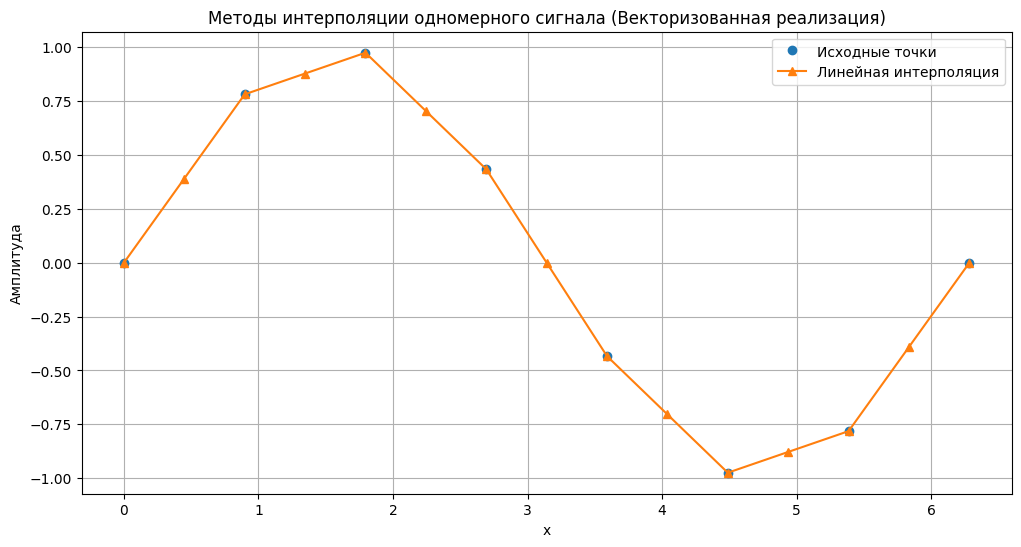

interactive(children=(Checkbox(value=True, description='original'), Checkbox(value=True, description='nn'), Ch…

In [13]:
from ipywidgets import interactive

original_length = 8
SCALE = 2 - 1 / original_length
x_original = np.linspace(0, 2 * np.pi, original_length)
signal = np.sin(x_original)
x_new = np.linspace(0, 2 * np.pi, int(original_length * SCALE))

#interpolated_signal_nn = interpolate(signal, SCALE, nearest_neighbor_kernel)
interpolated_signal_linear = interpolate(signal, SCALE, linear_kernel)
#interpolated_signal_cubic = interpolate(signal, SCALE, cubic_kernel)

fig, ax = plt.subplots(figsize=(12, 6))
line_original, = ax.plot(x_original, signal, 'o', label='Исходные точки')
#line_nn, = ax.plot(x_new, interpolated_signal_nn, 's-', label='Ближайший сосед')
line_linear, = ax.plot(x_new, interpolated_signal_linear, '^-', label='Линейная интерполяция')
#line_cubic, = ax.plot(x_new, interpolated_signal_cubic, 'd-', label='Кубическая интерполяция')

plt.legend()
plt.title('Методы интерполяции одномерного сигнала (Векторизованная реализация)')
plt.xlabel('x')
plt.ylabel('Амплитуда')
plt.grid(True)

def toggle_lines(original=True, nn=True, linear=True, cubic=True):
    line_original.set_visible(original)
    #line_nn.set_visible(nn)
    line_linear.set_visible(linear)
    #line_cubic.set_visible(cubic)
    plt.draw()

checkboxes = interactive(toggle_lines, original=True, nn=True, linear=True, cubic=True)
display(checkboxes)
plt.show()


### Интерполяция изображений

В этой части будут рассмотрены классические методы интерполяции изображений, реализованные в библиотеке OpenCV.

#### Подготовка изображений

Для выполнения этого задания предлагается использовать заранее подготовленные функции в модуле useful_utils. 

Для начала давайте попробуем считать изображение и отобразить его в интерактивном окне. Убедитесь, что `matplotlib widget` работает корректно, попробуйте с его помощью детально рассмотреть тестовое изображение. 

In [14]:
from useful_utils import read_image, show_images
from useful_utils import patch_batch, plot_interactive_heatmap, preprocess_image, interactive_plot_metrics
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

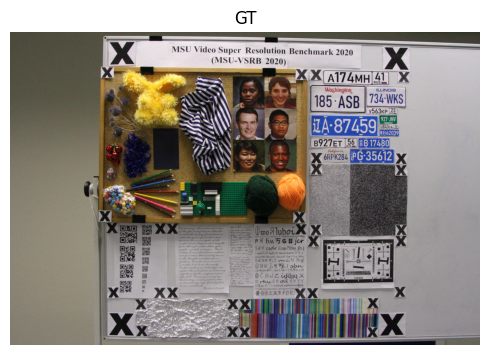

In [15]:
gt_path = Path('board.png')
gt = read_image(gt_path)
show_images([gt], ['GT'])

Создадим изображение низкого разрешения, в англоязычной нотации _LQ (Low Quality)_. Самый простой и распространенный способ сделать это — бикубическая интерполяция. 

Почитать про более продвинутые пайплайны деградации изображений можно [тут](https://arxiv.org/pdf/2107.10833). В большинстве современных работ используют именно этот метод.

In [16]:
SCALE = 4 

height, width = gt.shape[:2]
new_height, new_width = height // SCALE, width // SCALE
lq = cv2.resize(gt, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

if not os.path.exists("./LQs"):
    os.makedirs("./LQs")
cv2.imwrite("LQs/board.png", lq[..., ::-1])

True

Прочитаем искаженное изображение и попробуем восстановить его до исходного разрешения с помощью интерполяции методом ближацшего соседа. Рассмотрим искажения, возникающие в высокочастотных областях изображения.

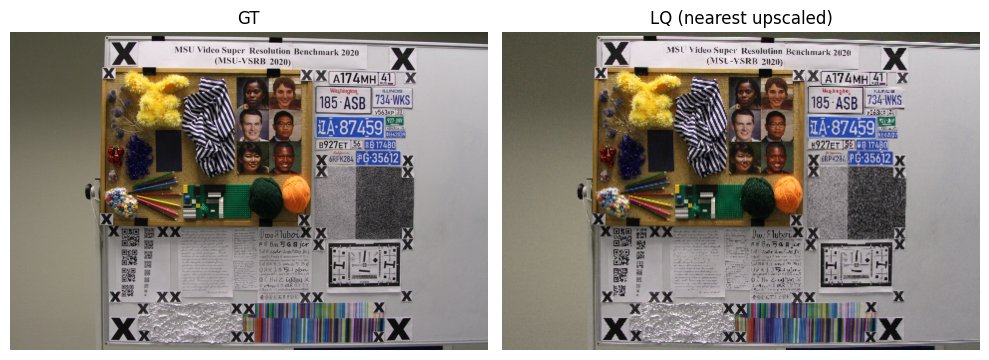

In [17]:
lq_path = Path('LQs/board.png')
lq = read_image(lq_path)
nearest = cv2.resize(lq, (width, height), interpolation=cv2.INTER_NEAREST)
show_images([gt, nearest], ['GT', 'LQ (nearest upscaled)'])

#### Объективная оценка качества

Для того, чтобы оценить, насколько результат работы SR совпадает с исходным изображением, необходимо использовать объективный метод оценки качества изображений. 

В качестве основных объективных методов оценки качества изображений в задаче Super-Resolution в статьях обычно используют [PSNR](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio) и [SSIM](https://ieeexplore.ieee.org/document/1284395). На данном семинаре мы реализуем более простую метрику MSE:

$$
MSE(x, y) = \frac{1}{n\times m} \sum_{i,j=0}^{n, m}{(x_i,j - y_i,j)^2}
$$



In [18]:
def mse(gt, image):
    assert gt.shape == image.shape, "MSE: image shapes mismatch"
    height, width = gt.shape[1], gt.shape[2]
    return 1 / (width * height) * ((gt - image) ** 2).sum()

In [19]:
def metric(im1, im2, metric_fn):
    return metric_fn(preprocess_image(im1, device)[None, ...], preprocess_image(im2, device)[None, ...]).item()

In [20]:
print(f"MSE между gt и nearest составляет {metric(gt, nearest, mse): .2f}")

MSE между gt и nearest составляет  43.22


## Существующие нейросетевые методы SR

В этом блоке вам предстоит запустить три модели Image Super-Resolution. Допускается как использование образцов кода для запуска в файлах `inference.py` каждого из репозиториев, так и воспользоваться возможностями Jupyter с помощью синтаксиса [`!command`](http://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-system).

Для оценки этой части задания необходимо загрузить в систему выходы моделей на рассмотренном ранее изображении `LQs/board.png`, на котором вы можете проверить себя с помощью assert-ов, и на изображении `LQs/zaya.png`, целевые значения для которого скрыты.

In [21]:
EPS = 3

def l2_norm(image1, image2):
    # Step 1: Normalize both images to the range [0, 1]
    if image1.max() > 1:
        image1 = image1 / 255.0
    if image2.max() > 1:
        image2 = image2 / 255.0
    
    # Step 2: Compute L2 norm between the two images
    return np.linalg.norm(image1 - image2)

### ESPCN

[ESPCN](https://github.com/Lornatang/ESPCN-PyTorch/tree/mastero) - популярный метод повышения разрешения, известной своей простотой. Ниже представлена его реализация.

Попробуем запустить этот метод и визуально оценить его результаты.

In [22]:
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, Tensor


class ESPCN(nn.Module):
    def __init__(
            self,
            in_channels: int,
            out_channels: int,
            channels: int, 
            upscale_factor: int):
        super(ESPCN, self).__init__()
        hidden_channels = channels // 2
        out_channels = int(out_channels * (upscale_factor ** 2))

        # Feature mapping
        self.feature_maps = nn.Sequential(
            nn.Conv2d(in_channels, channels, (5, 5), (1, 1), (2, 2)),
            nn.Tanh(),
            nn.Conv2d(channels, hidden_channels, (3, 3), (1, 1), (1, 1)),
            nn.Tanh(),
        )

        # Sub-pixel convolution layer
        self.sub_pixel = nn.Sequential(
            nn.Conv2d(hidden_channels, out_channels, (3, 3), (1, 1), (1, 1)),
            nn.PixelShuffle(upscale_factor),
        )

        
    def forward(self, x: Tensor) -> Tensor:
        x = self.feature_maps(x)
        x = self.sub_pixel(x)

        x = torch.clamp_(x, 0.0, 1.0)

        return x

In [23]:
model = ESPCN(in_channels = 1, out_channels = 1, channels = 64, upscale_factor=4)
model.load_state_dict(torch.load("./ESPCN_x4.pth.tar", map_location=torch.device('cpu'))["state_dict"])

C:\Users\ezgor\AppData\Local\Temp\ipykernel_33724\2417393091.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./ESPCN_x4.pth.tar", map_l

<All keys matched successfully>

In [24]:
imgname = "board"
path = f"LQs/{imgname}.png"
window_size = 16

img = cv2.imread(path, cv2.IMREAD_COLOR).astype(np.float32) / 255.
img = torch.from_numpy(np.transpose(img[:, :, [2, 1, 0]], (2, 0, 1))).float().unsqueeze(0)

h, w = img.shape[2], img.shape[3]
lr_image_r = img[:, 0, :, :].view(-1, 1, h, w)
lr_image_g = img[:, 1, :, :].view(-1, 1, h, w)
lr_image_b = img[:, 2, :, :].view(-1, 1, h, w)

sr_image_r = model(lr_image_r)
sr_image_g = model(lr_image_g)
sr_image_b = model(lr_image_b)

sr_output = torch.stack([sr_image_r, sr_image_g, sr_image_b]).view(3, h * SCALE, w * SCALE)
sr_output = sr_output.float().detach().cpu().clamp_(0, 1).numpy()

sr_output = np.transpose(sr_output[[2, 1, 0], :, :], (1, 2, 0))
sr_output = (sr_output * 255.0).round().astype(np.uint8)

if not os.path.exists("./results/ESPCN"):
    os.makedirs("./results/ESPCN")
cv2.imwrite(f'results/ESPCN/{imgname}_ESPCN-L_X4.png', sr_output)

espcn = read_image(f'results/ESPCN/{imgname}_ESPCN-L_X4.png')

### Визуализация работы методов

#### Субъективная оценка качества

Визуально сравните качество работы методов, воспользовавшись функцией `show_images`из предыдущего раздела.

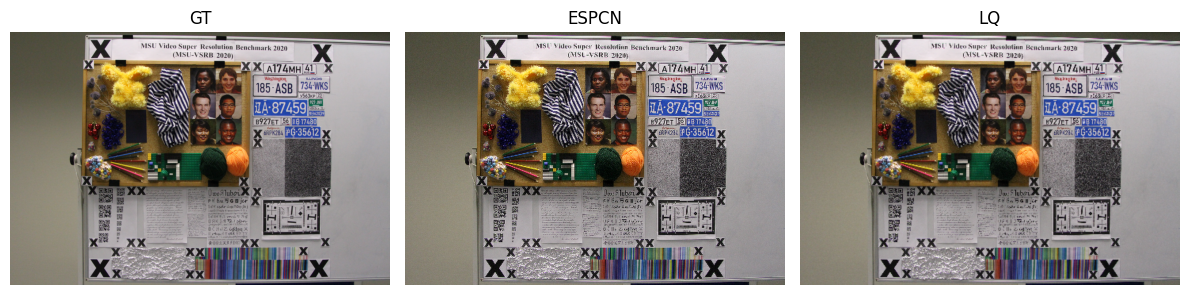

In [25]:
show_images([gt, espcn, nearest], ['GT', 'ESPCN', "LQ"], figsize=4)

#### Объекстивная оценка качества

Посчитайте SSIM, PSNR и MSE для полученных изображений и визуализируйте результат, воспользовавшись функцией `interactive_plot_metrics` из предыдущего раздела.

In [26]:
from torchmetrics import PeakSignalNoiseRatio
psnr = PeakSignalNoiseRatio(data_range=1.0, base=10.0, reduction=None, dim=[1, 2, 3])
psnr.eval()

from torchmetrics import StructuralSimilarityIndexMeasure
ssim = StructuralSimilarityIndexMeasure(gaussian_kernel=True, 
                         sigma=1.5, 
                         kernel_size=11, 
                         reduction=None, 
                         data_range=1.0, 
                         k1=0.01, 
                         k2=0.03, 
                         return_full_image=False, 
                         return_contrast_sensitivity=False)
ssim.eval()

e:\BMK\VG\SR-course\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
e:\BMK\VG\SR-course\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(


_StructuralSimilarityIndexMeasure()

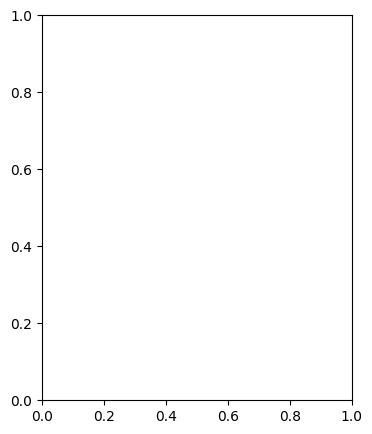

interactive(children=(Dropdown(description='Metric:', options=('SSIM↑', 'MSE↑', 'PSNR↑'), value='SSIM↑'), Outp…

In [27]:
data = {
    'Метод': ['BI', 'ESPCN'],
    'SSIM↑': [metric(gt, nearest, ssim), metric(gt, espcn, ssim)],
    'PSNR↑': [metric(gt, nearest, psnr), metric(gt, espcn, psnr)],
    'MSE↑': [metric(gt, nearest, mse), metric(gt, espcn, mse)],
}

interactive_plot_metrics(data)

## Нейросетевые артефакты

### Что еще за артефакты?

In [28]:
# в этом разделе рассмотрим часть стенда с пробковой доской
board_gt = gt[140:780, 370:1200, ...]
board_espcn = espcn[140:780, 370:1200, ...]

Как вы могли заметить, подходы на основе нейронных сетей могут неожиданно порождать визуальные артефакты на некоторых изображениях. Поэтому в данном разделе мы предлагаем вам разработать методы для отдельного обнаружения таких артефактов. 

Для ознакомления предлагаем воспользоваться функцией `patch_batch`, считающей значение метрики, например PSNR, по патчам изображений с некоторым шагом. 

Функция `plot_interactive_heatmap` позволит увидеть области, на которых присутствуют наибольшие "по мнению PSNR" искажения. Обратите внимание, что с помощью ползунка можно менять прозрачность тепловой карты PSNR, а кнопка в углу переключает изображения на фоне.

In [29]:
from useful_utils import patch_batch, plot_interactive_heatmap, preprocess_image

In [30]:
heatmap = patch_batch(
    gt=preprocess_image(board_gt, device=device),
    sample=preprocess_image(board_espcn, device=device),
    patch_size=32,
    metric=ssim,
    device=device,
    stride=4
).cpu().detach().numpy()
torch.cuda.empty_cache()

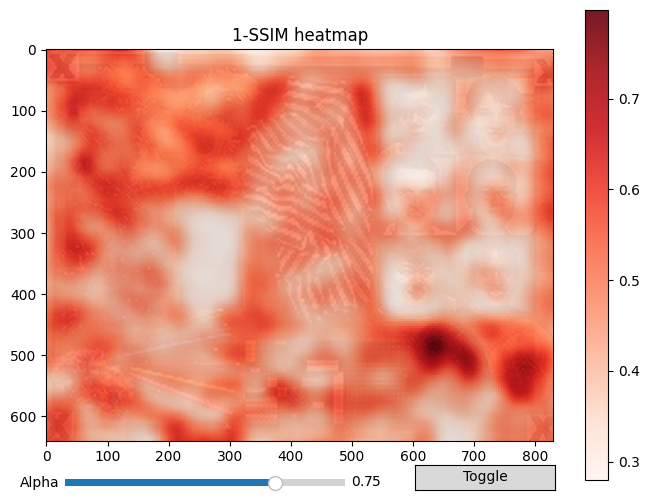

In [31]:
plot_interactive_heatmap(preprocess_image(board_gt, 'cpu'), preprocess_image(board_espcn, 'cpu'), 1-heatmap, "1-SSIM heatmap")

### Классификация областей с артефактами (5 баллов)

В реальных сценариях наличие GT не гарантированно, поэтому в данной части задания данные будут иметь следующий формат: датасет состоит из пятерок $ (SR, Bic, Mask, Model\_Name, Prob) $, где 
- $ SR $ и $ Bic $ — версии повышенного разрешения одного и того же изображения с помощью бикубической интерполяции и модели Super-Resolution;
- $ Model\_Name $ — название модели $ SR $, с помощью которой производилось повышение разрешения;
- $ Mask $ — бинарная маска предполагаемой области артефакта;
- $ Prob $ — вероятность наличия артефакта ($ 1 $ в случае, если в этой области содержится артефакт).

Вам будет предоставлена открытая часть датасета, на которой можно обучить любую модель предсказания меток $ Prob $ по остальным четырем входным признакам. Оценка качества модели будет осуществляться с помощью метрики [_ROC-AUC_](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc) на закрытой части датасета.

Разметка датасета находится в файле _data.csv_. Имена изображений $ SR, Bic $ и $ Mask $ находятся в столбцах _sr_name_, _bic_name_ и _mask_name_ соответственно. Сами изображения лежат в поддиректориях _sr_, _bic_, _masks_ предоставленного вам файла с данными.  $ Model\_Name $ и $ Prob $ хранятся в столбцах _model_name_ и _artifact_prob_ соответственно. Для удобства ниже представлен интерфейс для работы с датасетом, который вы при необходимости можете изменить (например, учесть, что признак $ Model\_Name $ является категориальным):

In [32]:
from PIL import Image
from torchvision import transforms
from useful_utils import prepare_contour, ArtifactDataset

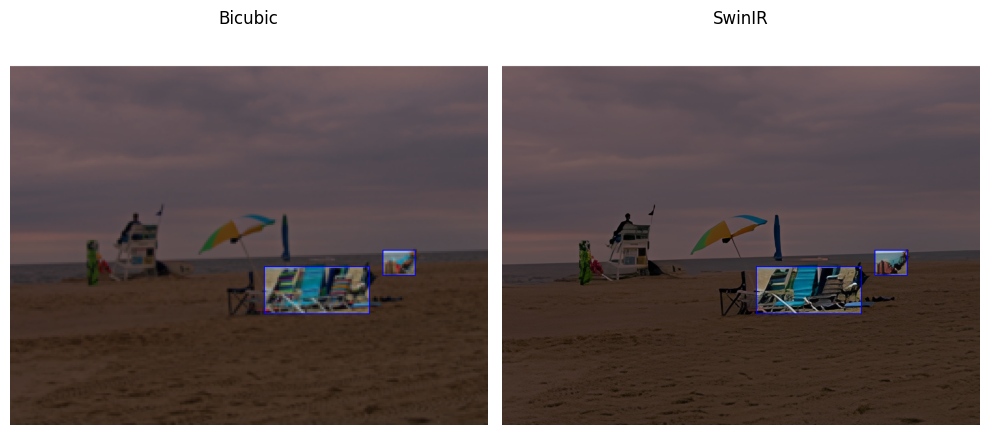

ВЕРОЯТНОСТЬ НАХОЖДЕНИЯ АРТЕФАКТА В ВЫДЕЛЕННОЙ ОБЛАСТИ:  0.27


In [33]:
# Пример использования:

# Трансформации для изображений
transform = transforms.Compose([
    transforms.ToTensor()
])

# Путь к csv файлу и директориям с изображениями
csv_file = 'artifacts_dataset/public/data.csv'
root_dir = 'artifacts_dataset/public/'

# Создание экземпляра датасета
artifact_dataset = ArtifactDataset(csv_file=csv_file, root_dir=root_dir, transform=transform)

# Пример получения первого элемента датасета
sample = artifact_dataset[42]

sr, bic, mask = sample["sr"].numpy(), sample["bic"].numpy(), sample["mask"].numpy()
demo = prepare_contour(np.transpose(bic, (1, 2, 0))*255, np.transpose(sr, (1, 2, 0))*255, mask[0])
show_images(demo, ["Bicubic", sample["model_name"]])
print(f"ВЕРОЯТНОСТЬ НАХОЖДЕНИЯ АРТЕФАКТА В ВЫДЕЛЕННОЙ ОБЛАСТИ: {sample['prob']: .2f}")

Интерфейс вашей модели должен соответствовать бейзлайну, реализованному в _artifacts_utils_. Менять базовый класс не нужно, для совместимости с тестирующей системой ваша модель должна наследоваться от _BaseModel_. Использование фреймворков не ограничено; допускается использование эвристик, обучение моделей из sklearn и написание своих на PyTorch (или на что еще вам хватит фантазии).

В тестовую систему необходимо загрузить заполненный файл _artifacts.py_, содержащий ваш класс _MyModel_ для работы с моделью, и ее сохраненные параметры. Для оценки будет испольщоваться метод _evaluate_ базовой модели.

Для получения максимального балла за эту часть задания вам нужно сделать ее лучше всех ;)

В качестве примера использования шаблона обучим бейзлайн на значениях psnr между $ SR $ и $ Bic $:

In [34]:
from useful_utils import BaseModel

In [35]:
import sklearn
import joblib

In [39]:
# GRADED CELL: MyModel

class MyModel(BaseModel):
    def __init__(self):
        super().__init__()
        from sklearn.linear_model import LinearRegression
        self.model = LinearRegression()

    def preprocess_data(self, dataset):
        from skimage.metrics import peak_signal_noise_ratio as psnr
    
        # Список для хранения значений PSNR и меток
        psnr_values = []
        labels = []
        for i in range(len(dataset)):
            sample = dataset[i]
            sr_image, bic_image, prob = sample["sr"], sample["bic"], sample["prob"]

            # PSNR между изображениями SR и Bic
            sr_image = sr_image.permute(1, 2, 0).numpy()  # Конвертируем тензор в numpy для использования в psnr
            bic_image = bic_image.permute(1, 2, 0).numpy()
            
            psnr_value = psnr(sr_image, bic_image, data_range=1.0)
            
            psnr_values.append(psnr_value)
            labels.append(prob)

        # Преобразуем списки в массивы numpy
        X = np.array(psnr_values).reshape(-1, 1)  # PSNR в качестве признаков
        y = np.array(labels)  # Метки
        return X, y

    def fit(self, dataset):
        X_train, y_train = self.preprocess_data(dataset)
        self.model.fit(X_train, y_train)

    def predict(self, unlabled_dataset):
        X_train, _ = self.preprocess_data(unlabled_dataset)
        return self.model.predict(X_train)

    def save_weights(self, path):
        joblib.dump(self.model, path)
        print(f"Модель сохранена в {path}")

    def load_weights(self, path):
        self.model = joblib.load(path)
        print(f"Модель загружена из {path}")

In [40]:
train_dataset, test_dataset = torch.utils.data.random_split(artifact_dataset, [0.8, 0.2])

In [41]:
psnr_model = MyModel()
psnr_model.fit(train_dataset)
psnr_model.save_weights('psnr_model.pkl')

Модель сохранена в psnr_model.pkl


In [42]:
# Загрузка модели и предсказания
psnr_model = MyModel()
psnr_model.load_weights('psnr_model.pkl')

# Оценка модели
roc_auc = psnr_model.__evaluate__(test_dataset, metric="roc_auc")
print(f"ROC-AUC на тестовых данных: {roc_auc:.4f}")

mse = psnr_model.__evaluate__(test_dataset, metric="mse")
print(f"MSE на тестовых данных: {mse:.4f}")

Модель загружена из psnr_model.pkl
ROC-AUC на тестовых данных: 0.4420
MSE на тестовых данных: 0.0734
